In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("ddos.csv")

**DATA PROCESSING**

In [ ]:
data.shape

(225745, 79)

In [ ]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [ ]:
# ca pour supprimer les espace
data.columns=data.columns.str.strip()

In [ ]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [ ]:
data["Label"].value_counts()

,count
Label,
DDoS,128027
BENIGN,97718


In [ ]:
print(data['Label'].unique())

['BENIGN' 'DDoS']


In [ ]:
data.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
# affiche les valeurs null
print(data.isnull().sum().sort_values(ascending=False))

Flow Bytes/s                   4
Flow Duration                  0
Destination Port               0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [ ]:
#pour supp les valeur null
new_data=data.dropna()
print(new_data.isnull().sum().sort_values(ascending=False))

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [ ]:
# ici on supprime les valeurs infini
new_data = new_data.replace([np.inf, -np.inf], np.nan).dropna()

In [ ]:

# Vérifiez d'abord les colonnes actuelles
print("Colonnes avant suppression :")
print(new_data.columns.tolist())
print(f"Nombre de colonnes : {len(new_data.columns)}")

# Supprimer la colonne dupliquée 'Fwd Header Length.1'
if 'Fwd Header Length.1' in new_data.columns:
    new_data = new_data.drop(columns=['Fwd Header Length.1'])
    print("\n✅ Colonne 'Fwd Header Length.1' supprimée !")
else:
    print("\n⚠️ La colonne 'Fwd Header Length.1' n'existe pas dans vos données")

# Vérifier après suppression
print(f"\nColonnes après suppression :")
print(new_data.columns.tolist())
print(f"Nombre de colonnes : {len(new_data.columns)}")

Colonnes avant suppression :
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE

In [ ]:
#ajout colonne attack pour une classification binaire
new_data['attack'] = (new_data['Label'] != 'BENIGN').astype(int)

(new_data['attack'].value_counts())

,count
attack,
1,128025
0,97686


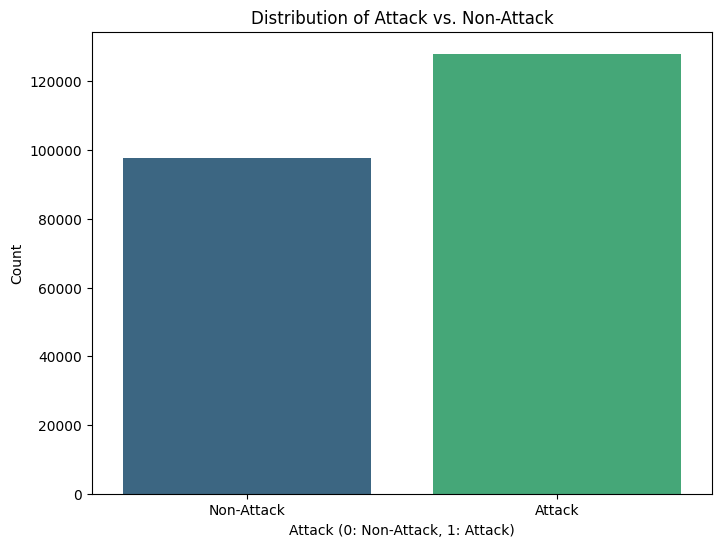

In [ ]:
#histograme de nombre d attack et normal
plt.figure(figsize=(8, 6))
sns.countplot(x='attack', hue='attack', data=new_data, palette='viridis', legend=False)
plt.title('Distribution of Attack vs. Non-Attack')
plt.xlabel('Attack (0: Non-Attack, 1: Attack)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Attack', 'Attack'])
plt.show()

In [ ]:
# supprime la coolonne label et garder just la colonne attak
new_data = new_data.drop("Label",axis=1)


In [ ]:
new_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [ ]:
# Calculer la corrélation avec 'attack'
correlation = new_data.corr()['attack'].sort_values(ascending=False)
print("Top 20 des features les plus corrélées avec les attaques :")
print(correlation.head(20))



Top 20 des features les plus corrélées avec les attaques :
attack                    1.000000
Bwd Packet Length Mean    0.603258
Avg Bwd Segment Size      0.603258
Bwd Packet Length Max     0.577287
Bwd Packet Length Std     0.576122
Packet Length Mean        0.454211
Average Packet Size       0.453399
Packet Length Std         0.443681
Max Packet Length         0.414329
Packet Length Variance    0.408037
PSH Flag Count            0.247660
Flow IAT Std              0.129560
Flow IAT Mean             0.127428
Fwd IAT Max               0.105396
Flow IAT Max              0.100588
Fwd IAT Std               0.099588
ACK Flag Count            0.097094
Idle Max                  0.096712
Idle Mean                 0.087051
Idle Std                  0.077988
Name: attack, dtype: float64


In [ ]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225711 entries, 0 to 225744
Data columns (total 78 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225711 non-null  int64  
 1   Flow Duration                225711 non-null  int64  
 2   Total Fwd Packets            225711 non-null  int64  
 3   Total Backward Packets       225711 non-null  int64  
 4   Total Length of Fwd Packets  225711 non-null  int64  
 5   Total Length of Bwd Packets  225711 non-null  int64  
 6   Fwd Packet Length Max        225711 non-null  int64  
 7   Fwd Packet Length Min        225711 non-null  int64  
 8   Fwd Packet Length Mean       225711 non-null  float64
 9   Fwd Packet Length Std        225711 non-null  float64
 10  Bwd Packet Length Max        225711 non-null  int64  
 11  Bwd Packet Length Min        225711 non-null  int64  
 12  Bwd Packet Length Mean       225711 non-null  float64
 13  Bwd 

In [ ]:
new_data.shape


(225711, 78)

In [ ]:
new_data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [ ]:
from sklearn.model_selection import train_test_split

# Separation des features (X) et target (y)
X = new_data.drop('attack', axis=1)
y = new_data['attack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (157997, 77)
Test set size: (67714, 77)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score,recall_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("RANDOM FOREST")


rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

RANDOM FOREST


In [ ]:
# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

# Affichage des métriques
print(f" Métriques :")
print(f"  • Accuracy  :  ({accuracy*100:.2f}%)")
print(f"  • Precision : ({precision*100:.2f}%)")
print(f"  • Recall    : ({recall*100:.2f}%)")
print(f"  • F1-Score  : ({f1*100:.2f}%)")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
print(f" Matrice de confusion :")
print(f"                 Prédit")
print(f"              Normal  Attaque")
print(f"  Normal      {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"  Attaque     {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\n📈 Classification Report détaillé :")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attaque']))

 Métriques :
  • Accuracy  :  (99.99%)
  • Precision : (99.99%)
  • Recall    : (99.99%)
  • F1-Score  : (99.99%)
 Matrice de confusion :
                 Prédit
              Normal  Attaque
  Normal       29304       2
  Attaque          5   38403

📈 Classification Report détaillé :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     29306
     Attaque       1.00      1.00      1.00     38408

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



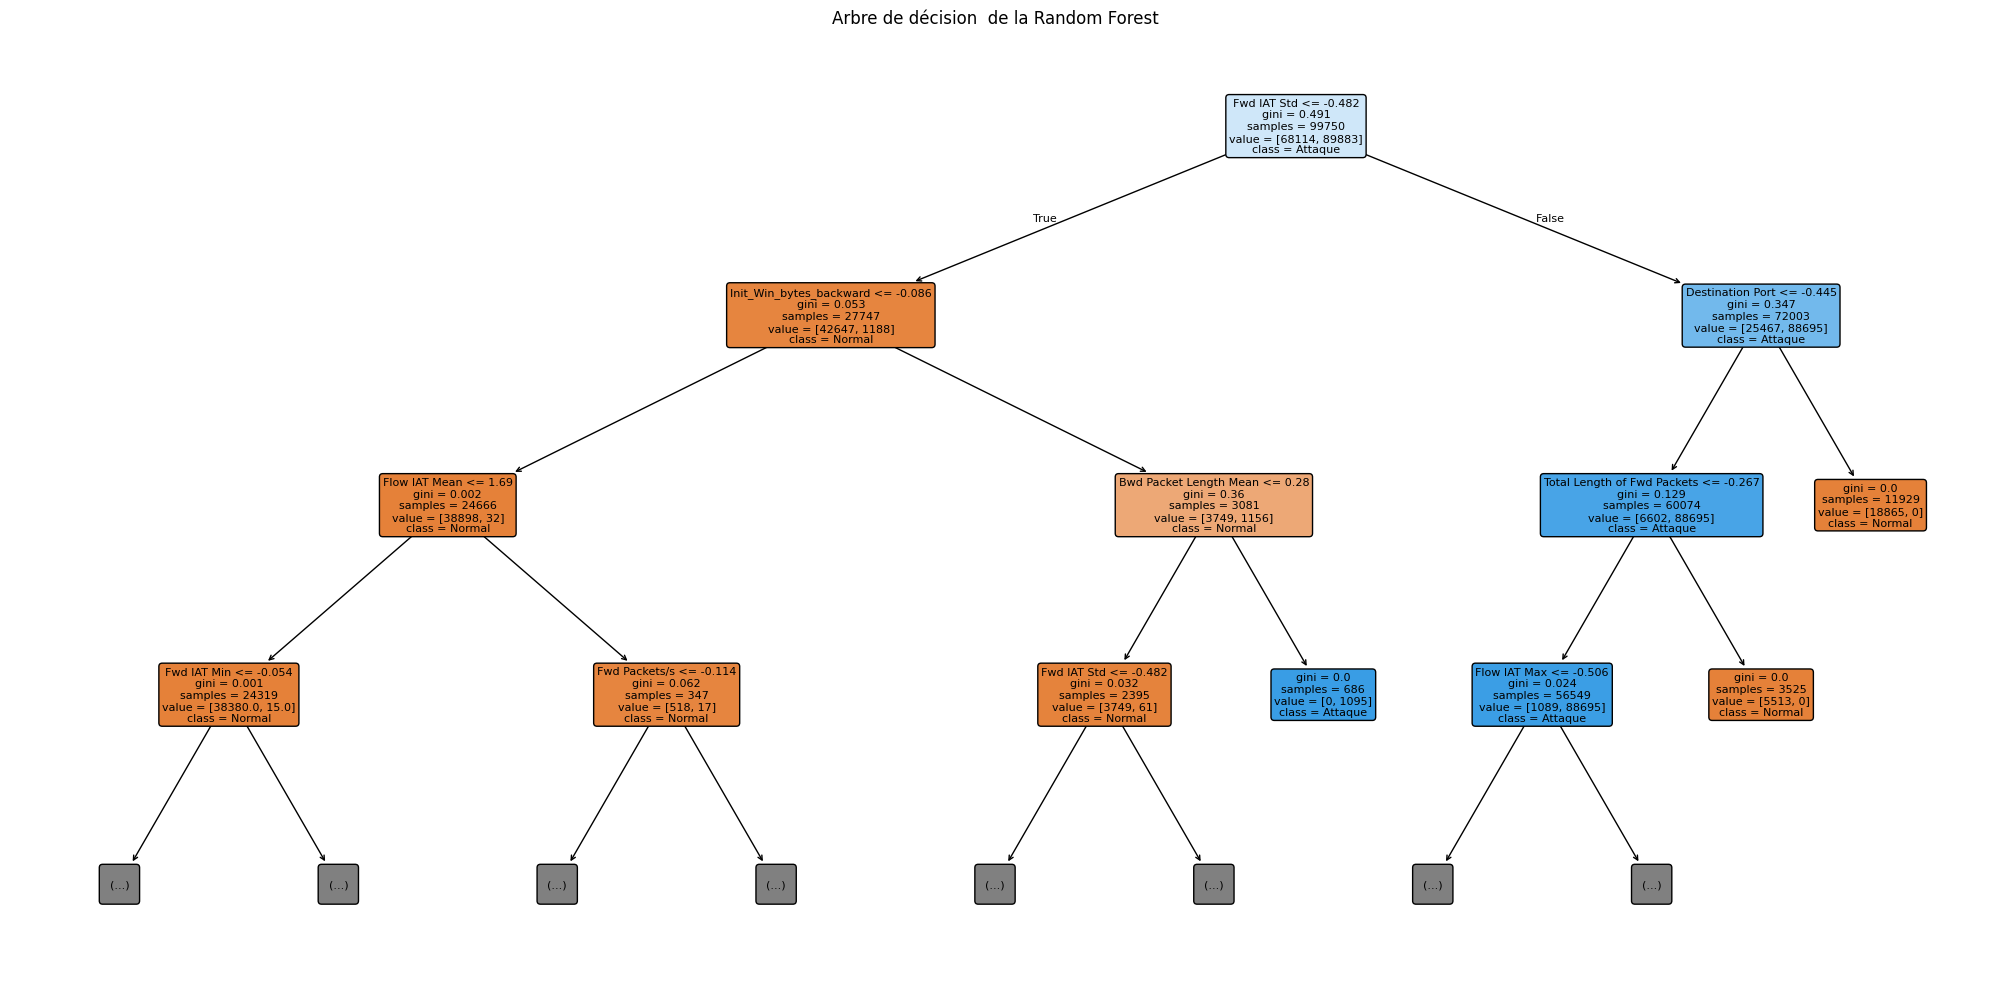

In [ ]:
from sklearn.tree import plot_tree

# Prendre un arbre de la forêt
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=list(X_train.columns),  # Noms de vos 78 colonnes
          class_names=['Normal', 'Attaque'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Limiter la profondeur pour lisibilité
plt.title("Arbre de décision  de la Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils import resample
from sklearn.svm import SVC

In [ ]:
# n_samples=50000 c est pour prondre un partie des donner car svm rbf consome la ram et prende de temps
print("SVM avec resampling")
X_train_svm, y_train_svm = resample(X_train_scaled, y_train, n_samples=50000, random_state=42)
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train_svm, y_train_svm)  # ← Utilise SEULEMENT 50 000 échantillons
y_pred_svm = svm.predict(X_test_scaled)

SVM avec resampling


In [ ]:
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

# Affichage des métriques
print(f"\n📊 Métriques :")
print(f"  • Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"  • Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"  • F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm)
print(f"\n📋 Matrice de confusion :")
print(f"                 Prédit")
print(f"              Normal  Attaque")
print(f"  Normal      {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"  Attaque     {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\n📈 Classification Report détaillé :")
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Attaque']))


📊 Métriques :
  • Accuracy  : 0.9957 (99.57%)
  • Precision : 0.9934 (99.34%)
  • Recall    : 0.9990 (99.90%)
  • F1-Score  : 0.9962 (99.62%)

📋 Matrice de confusion :
                 Prédit
              Normal  Attaque
  Normal       29053     253
  Attaque         39   38369

📈 Classification Report détaillé :
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     29306
     Attaque       0.99      1.00      1.00     38408

    accuracy                           1.00     67714
   macro avg       1.00      1.00      1.00     67714
weighted avg       1.00      1.00      1.00     67714



In [ ]:
# Test avec vraie ligne BENIGN de new_data
benign_row = new_data[new_data['attack'] == 0].iloc[0]
X_test     = pd.DataFrame([benign_row[X.columns]], columns=X.columns)
X_scaled   = scaler.transform(X_test)

pred  = rf.predict(X_scaled)[0]
proba = rf.predict_proba(X_scaled)[0]

print(f"Pred  : {pred}  → {'BENIGN ✅' if pred==0 else 'DDoS ❌'}")
print(f"Proba : [BENIGN={proba[0]*100:.1f}%  |  DDoS={proba[1]*100:.1f}%]")

Pred  : 0  → BENIGN ✅
Proba : [BENIGN=100.0%  |  DDoS=0.0%]
